# **Part 1**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from google.colab import drive
drive.mount('/content/drive')
file_path1='/content/drive/MyDrive/Original_Data_with_Row_Mean.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
df1 = pd.read_csv(file_path1)
df1.columns = df1.columns.str.strip().str.replace('%', '_pct').str.replace(' ', '_')

def clean_range(val):
    if isinstance(val, str):
        nums = [float(x) for x in val.replace('%','').split('-')]
        return sum(nums)/len(nums)
    return val

for col in ['Temperature_C', 'Humidity__pct', 'Soil_Moisture__pct', 'Pest_Risk__pct']:
    df1[col] = df1[col].apply(clean_range)

df1.dropna(inplace=True)

print("Cleaned Data:")
print(df1.head())

Cleaned Data:
   Sensor_ID Product_Name Product_Type     Weather_Preference  \
0          1        Wheat  Cereal Crop      Cool & Dry (Rabi)   
1          2         Rice  Cereal Crop  Warm & Humid (Kharif)   
2          3        Mango   Fruit Tree      Warm & Dry Summer   
3          4        Apple   Fruit Tree       Cold & Temperate   
4          5       Banana   Fruit Crop           Warm & Humid   

      States_Preference     Region_Preference  Soil_Moisture__pct  \
0        Punjab, UP, MP                Plains                25.0   
1     WB, TN, AP, Bihar           Plain/Delta                50.0   
2       Maharashtra, UP  Tropical/Subtropical                20.0   
3  HP, J&K, Uttarakhand                 Hills                25.0   
4        TN, Kerala, MH              Tropical                70.0   

   Temperature_C  Humidity__pct  Pest_Risk__pct       Irrigation_Needed  \
0           20.0           55.0            20.0        Yes (2–3 cycles)   
1           30.0           80.

In [44]:
cluster_features = ['Temperature_C', 'Humidity__pct', 'Soil_Moisture__pct']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df1[cluster_features])
kmeans = KMeans(n_clusters=3, random_state=42)
df1['Cluster'] = kmeans.fit_predict(scaled_data)
print("\nCluster Added:")
print(df1[['Temperature_C', 'Cluster']].head())


Cluster Added:
   Temperature_C  Cluster
0           20.0        1
1           30.0        0
2           27.0        2
3           15.0        1
4           28.0        0


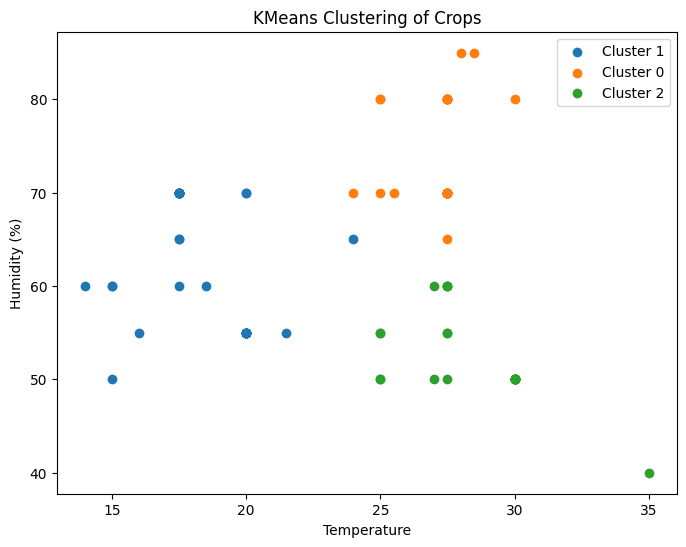

In [45]:
plt.figure(figsize=(8,6))

for cluster in df1['Cluster'].unique():
    cluster_data = df1[df1['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Temperature_C'],
        cluster_data['Humidity__pct'],
        label=f'Cluster {cluster}'
    )
plt.xlabel("Temperature")
plt.ylabel("Humidity (%)")
plt.title("KMeans Clustering of Crops")
plt.legend()

plt.show()

In [46]:
le = LabelEncoder()
df1['Crop_Encoded'] = le.fit_transform(df1['Product_Name'])
features = ['Crop_Encoded', 'Temperature_C', 'Humidity__pct', 'Soil_Moisture__pct', 'Cluster']
target = 'Pest_Risk__pct'

X = df1[features]
y = df1[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("\nModel Trained Successfully!")


Model Trained Successfully!


In [47]:
def predict_pest_risk(crop_name, temp, humidity, soil_moisture):
    if crop_name not in le.classes_:
        print(" Crop not found in dataset!")
        return

    crop_encoded = le.transform([crop_name])[0]
    input_scaled = scaler.transform([[temp, humidity, soil_moisture]])
    cluster = kmeans.predict(input_scaled)[0]
    input_data = pd.DataFrame([[crop_encoded, temp, humidity, soil_moisture, cluster]], columns=features)
    prediction = model.predict(input_data)[0]

    print(f"\n Crop: {crop_name}")
    print(f" Temperature: {temp}")
    print(f" Humidity: {humidity}")
    print(f" Soil Moisture: {soil_moisture}")
    print(f" Cluster: {cluster}")
    print(f" Predicted Pest Risk: {prediction:.2f}%")

crop_name= input("Enter crop name: ")
temp = float(input("Enter temperature: "))
humidity = float(input("Enter humidity: "))
soil_moisture = float(input("Enter soil moisture: "))

predict_pest_risk(crop_name, temp, humidity, soil_moisture)


Enter crop name: Rice
Enter temperature: 45
Enter humidity: 78
Enter soil moisture: 12

 Crop: Rice
 Temperature: 45.0
 Humidity: 78.0
 Soil Moisture: 12.0
 Cluster: 2
 Predicted Pest Risk: 26.00%


In [48]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f" RMSE: {rmse:.2f}")
print(f" MAE: {mae:.2f}")
print(f" R² Score: {r2:.2f}")

 RMSE: 3.78
 MAE: 2.42
 R² Score: 0.21


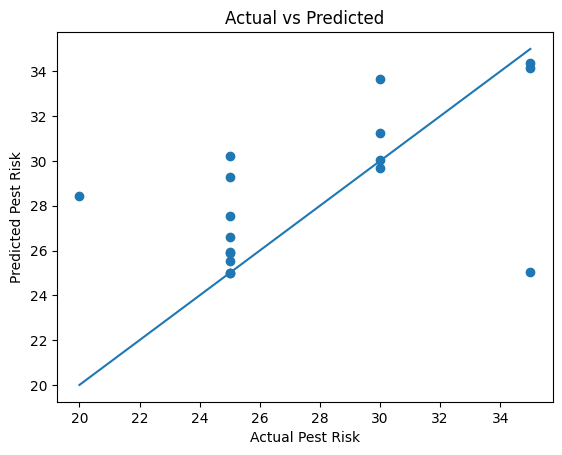

In [49]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Pest Risk")
plt.ylabel("Predicted Pest Risk")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.show()

# Part **2**

In [50]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [51]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/agriculture_pest_dataset_2000_rows.csv'
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Product_Name Product_Type     Weather_Preference     States_Preference  \
0        Wheat  Cereal Crop      Cool & Dry (Rabi)        Punjab, UP, MP   
1         Rice  Cereal Crop  Warm & Humid (Kharif)     WB, TN, AP, Bihar   
2        Mango   Fruit Tree      Warm & Dry Summer       Maharashtra, UP   
3        Apple   Fruit Tree       Cold & Temperate  HP, J&K, Uttarakhand   
4       Banana   Fruit Crop           Warm & Humid        TN, Kerala, MH   

      Region_Preference  Soil_Moisture_%  Temperature_C  Humidity_%  \
0                Plains             25.0           20.0        55.0   
1           Plain/Delta             50.0           30.0        80.0   
2  Tropical/Subtropical             20.0           27.0        60.0   
3                 Hills             25.0           15.0        50.0   
4              Tropical             70.0           28.0    

In [52]:
import re

def clean_value(x):
    if isinstance(x, str):
        nums = re.findall(r"\d+\.?\d*", x)
        return float(nums[0]) if nums else 0
    return x

cols_to_clean = ['Temperature_C', 'Humidity_%', 'Soil_Moisture_%']

for col in cols_to_clean:
    df[col] = df[col].apply(clean_value)

In [53]:
# Interaction features
df['Temp_Humidity'] = df['Temperature_C'] * df['Humidity_%']
df['Moisture_Humidity'] = df['Soil_Moisture_%'] * df['Humidity_%']
df['Temp_Moisture'] = df['Temperature_C'] * df['Soil_Moisture_%']

In [54]:
categorical_cols = ['Product_Name', 'Weather_Preference', 'States_Preference', 'Region_Preference']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [55]:
cluster_features = ['Temperature_C', 'Humidity_%', 'Soil_Moisture_%']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42)
df['Weather_Cluster'] = kmeans.fit_predict(scaled_data)

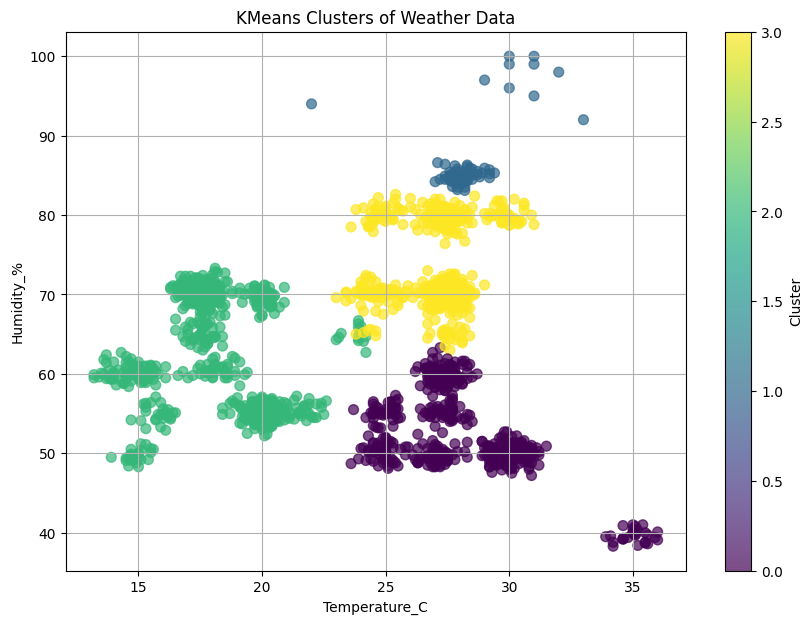

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(df['Temperature_C'], df['Humidity_%'], c=df['Weather_Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.title('KMeans Clusters of Weather Data')
plt.xlabel('Temperature_C')
plt.ylabel('Humidity_%')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

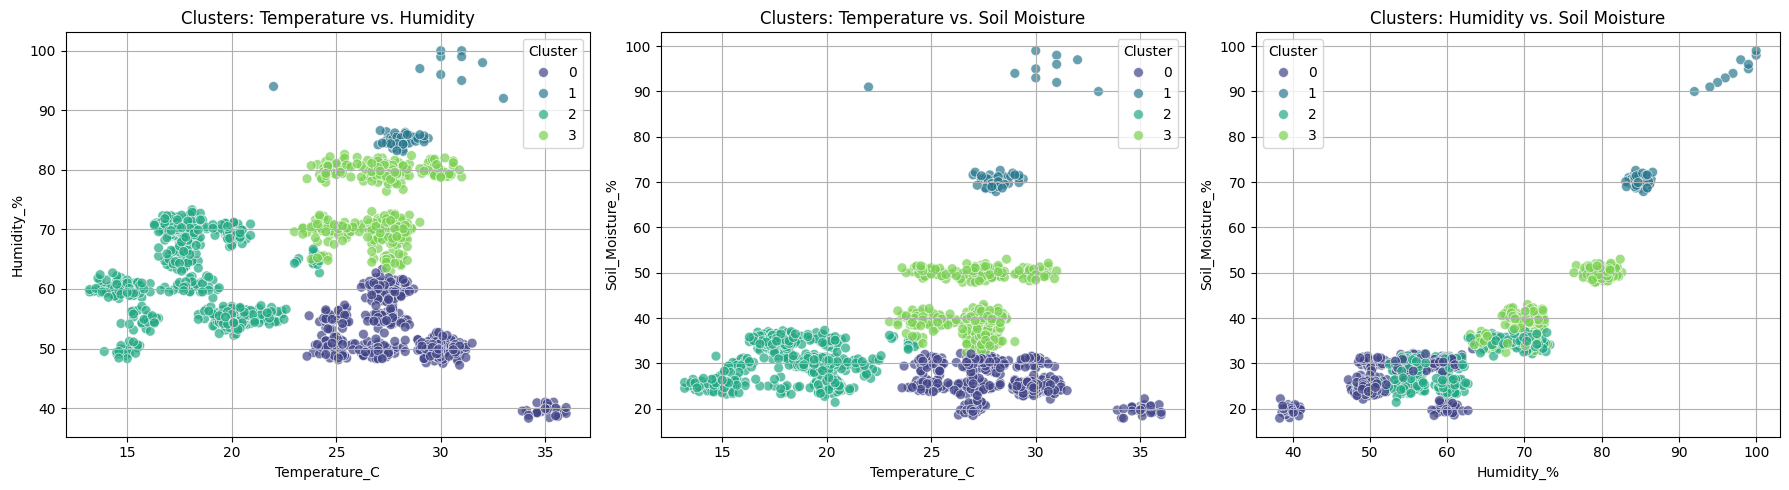

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the number of clusters
num_clusters = df['Weather_Cluster'].nunique()

# Define a color palette for consistent coloring across plots
palette = sns.color_palette('viridis', num_clusters)

plt.figure(figsize=(18, 5))

# Plot 1: Temperature_C vs. Humidity_%
plt.subplot(1, 3, 1)
sns.scatterplot(x='Temperature_C', y='Humidity_%', hue='Weather_Cluster', data=df, palette=palette, s=50, alpha=0.7)
plt.title('Clusters: Temperature vs. Humidity')
plt.xlabel('Temperature_C')
plt.ylabel('Humidity_%')
plt.grid(True)
plt.legend(title='Cluster')

# Plot 2: Temperature_C vs. Soil_Moisture_%
plt.subplot(1, 3, 2)
sns.scatterplot(x='Temperature_C', y='Soil_Moisture_%', hue='Weather_Cluster', data=df, palette=palette, s=50, alpha=0.7)
plt.title('Clusters: Temperature vs. Soil Moisture')
plt.xlabel('Temperature_C')
plt.ylabel('Soil_Moisture_%')
plt.grid(True)
plt.legend(title='Cluster')

# Plot 3: Humidity_% vs. Soil_Moisture_%
plt.subplot(1, 3, 3)
sns.scatterplot(x='Humidity_%', y='Soil_Moisture_%', hue='Weather_Cluster', data=df, palette=palette, s=50, alpha=0.7)
plt.title('Clusters: Humidity vs. Soil Moisture')
plt.xlabel('Humidity_%')
plt.ylabel('Soil_Moisture_%')
plt.grid(True)
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [58]:
X = df.drop(columns=['Pest_Risk_%'])
y = df['Pest_Risk_%']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [60]:
categorical_cols_to_encode = ['Product_Type', 'Irrigation_Needed', 'Fertilizer_Required', 'Pest_Name', 'Pesticide_name ']

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols_to_encode, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols_to_encode, drop_first=True)

# Align columns - this is crucial to ensure both datasets have the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [61]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train_encoded, y_train)

print("Training Accuracy:", model.score(X_train_encoded, y_train))
print("Testing Accuracy:", model.score(X_test_encoded, y_test))

Training Accuracy: 0.9979363194107527
Testing Accuracy: 0.9909448906750659


In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test_encoded)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 0.5308
MAE: 0.3882
R2 Score: 0.9909


In [63]:
def suggest_pest(risk):
    if risk > 75:
        return "High Risk Pest: Locusts / Armyworms"
    elif risk > 50:
        return "Moderate Risk Pest: Aphids / Whiteflies"
    else:
        return "Low Risk Pest: Minor insects"

In [64]:
def irrigation_advice(soil_moisture):
    if soil_moisture < 30:
        return "Increase irrigation "
    elif soil_moisture < 60:
        return "Maintain current irrigation"
    else:
        return "Reduce irrigation "

In [65]:
def predict_pest_risk_with_suggestions():
    # 1. Collect user inputs
    print("Please provide the following information:")
    crop_name = input("Enter Product Name (e.g., Wheat): ")
    product_type = input("Enter Product Type (e.g., Cereal Crop): ")
    weather_pref = input("Enter Weather Preference (e.g., Cool & Dry (Rabi)): ")
    states_pref = input("Enter States Preference (e.g., Punjab, UP, MP): ")
    region_pref = input("Enter Region Preference (e.g., Plains): ")
    temp = float(input("Enter Temperature (°C): "))
    humidity = float(input("Enter Humidity (%): "))
    soil_moisture = float(input("Enter Soil Moisture (%): "))
    fertilizer_req = input("Enter Fertilizer Required (e.g., Urea, DAP, Potash): ")

    # Create a base dictionary for fixed inputs
    fixed_input_data = {
        'Product_Name': crop_name,
        'Product_Type': product_type,
        'Weather_Preference': weather_pref,
        'States_Preference': states_pref,
        'Region_Preference': region_pref,
        'Soil_Moisture_%': soil_moisture,
        'Temperature_C': temp,
        'Humidity_%': humidity,
        'Fertilizer_Required': fertilizer_req
    }

    # 2. Preprocess fixed user inputs
    # Label Encoding
    encoded_fixed_data = {}
    for col, encoder in encoders.items():
        try:
            encoded_fixed_data[col] = encoder.transform([fixed_input_data[col]])[0]
        except ValueError:
            print(f"Warning: Input '{fixed_input_data[col]}' not found for '{col}'. Using a default value of 0.")
            encoded_fixed_data[col] = 0 # Fallback for unknown categories

    # Numerical and Interaction features
    encoded_fixed_data['Soil_Moisture_%'] = soil_moisture
    encoded_fixed_data['Temperature_C'] = temp
    encoded_fixed_data['Humidity_%'] = humidity
    encoded_fixed_data['Temp_Humidity'] = temp * humidity
    encoded_fixed_data['Moisture_Humidity'] = soil_moisture * humidity
    encoded_fixed_data['Temp_Moisture'] = temp * soil_moisture

    # Clustering
    cluster_input = scaler.transform([[temp, humidity, soil_moisture]])
    encoded_fixed_data['Weather_Cluster'] = kmeans.predict(cluster_input)[0]

    # 3. Get unique combinations for suggestions
    unique_irrigation = df['Irrigation_Needed'].unique()
    unique_pest_name = df['Pest_Name'].unique()
    unique_pesticide_name = df['Pesticide_name '].unique()

    min_risk = float('inf')
    best_combination = None

    # Ensure model_columns are defined for alignment
    if 'X_train_encoded' not in globals():
        print("Error: X_train_encoded not found. Please ensure all previous cells are executed.")
        return
    model_columns = X_train_encoded.columns.tolist()

    # 4. Loop through combinations to predict risk
    for irrig in unique_irrigation:
        for pest in unique_pest_name:
            for pesticide in unique_pesticide_name:
                # Create a temporary DataFrame for this specific combination
                current_data = {
                    'Product_Name': [encoded_fixed_data['Product_Name']],
                    'Product_Type': [fixed_input_data['Product_Type']],
                    'Weather_Preference': [encoded_fixed_data['Weather_Preference']],
                    'States_Preference': [encoded_fixed_data['States_Preference']],
                    'Region_Preference': [encoded_fixed_data['Region_Preference']],
                    'Soil_Moisture_%': [encoded_fixed_data['Soil_Moisture_%']],
                    'Temperature_C': [encoded_fixed_data['Temperature_C']],
                    'Humidity_%': [encoded_fixed_data['Humidity_%']],
                    'Fertilizer_Required': [fixed_input_data['Fertilizer_Required']],
                    'Temp_Humidity': [encoded_fixed_data['Temp_Humidity']],
                    'Moisture_Humidity': [encoded_fixed_data['Moisture_Humidity']],
                    'Temp_Moisture': [encoded_fixed_data['Temp_Moisture']],
                    'Weather_Cluster': [encoded_fixed_data['Weather_Cluster']],
                    'Irrigation_Needed': [irrig],
                    'Pest_Name': [pest],
                    'Pesticide_name ': [pesticide]
                }
                temp_df = pd.DataFrame(current_data)

                # Apply one-hot encoding for the categorical_cols_to_encode
                encoded_df = pd.get_dummies(temp_df, columns=categorical_cols_to_encode, drop_first=True)

                # Ensure all columns are present and in the correct order for the model
                # Use reindex with `fill_value=0` to add missing dummy columns and maintain order
                final_input_df = encoded_df.reindex(columns=model_columns, fill_value=0)

                # Predict
                prediction = model.predict(final_input_df)[0]

                if prediction < min_risk:
                    min_risk = prediction
                    best_combination = {'Irrigation_Needed': irrig, 'Pest_Name': pest, 'Pesticide_name': pesticide}

    print("\n--- Optimized Pest Management Suggestions ---")
    print("Predicted Minimum Pest Risk:", round(min_risk, 2), "%")
    if best_combination:
        print(" Suggested Irrigation Needed:", best_combination['Irrigation_Needed'])
        print(" Suggested Pest Name:", best_combination['Pest_Name'])
        print(" Suggested Pesticide Name:", best_combination['Pesticide_name'])
    else:
        print("Could not find a suitable combination.")

    print("General Pest Suggestion (based on predicted risk):", suggest_pest(min_risk))
    print("General Irrigation Advice (based on your soil moisture):", irrigation_advice(soil_moisture))


In [66]:
predict_pest_risk_with_suggestions()


Please provide the following information:
Enter Product Name (e.g., Wheat): Rice
Enter Product Type (e.g., Cereal Crop): Cereal
Enter Weather Preference (e.g., Cool & Dry (Rabi)): Cool & Dry
Enter States Preference (e.g., Punjab, UP, MP): WB
Enter Region Preference (e.g., Plains): Plains
Enter Temperature (°C): 45
Enter Humidity (%): 78
Enter Soil Moisture (%): 12
Enter Fertilizer Required (e.g., Urea, DAP, Potash): DAP

--- Optimized Pest Management Suggestions ---
Predicted Minimum Pest Risk: 27.08 %
 Suggested Irrigation Needed: Yes (2–3 cycles)
 Suggested Pest Name: Leaf Miner
 Suggested Pesticide Name: Fipronil
General Pest Suggestion (based on predicted risk): Low Risk Pest: Minor insects
General Irrigation Advice (based on your soil moisture): Increase irrigation 


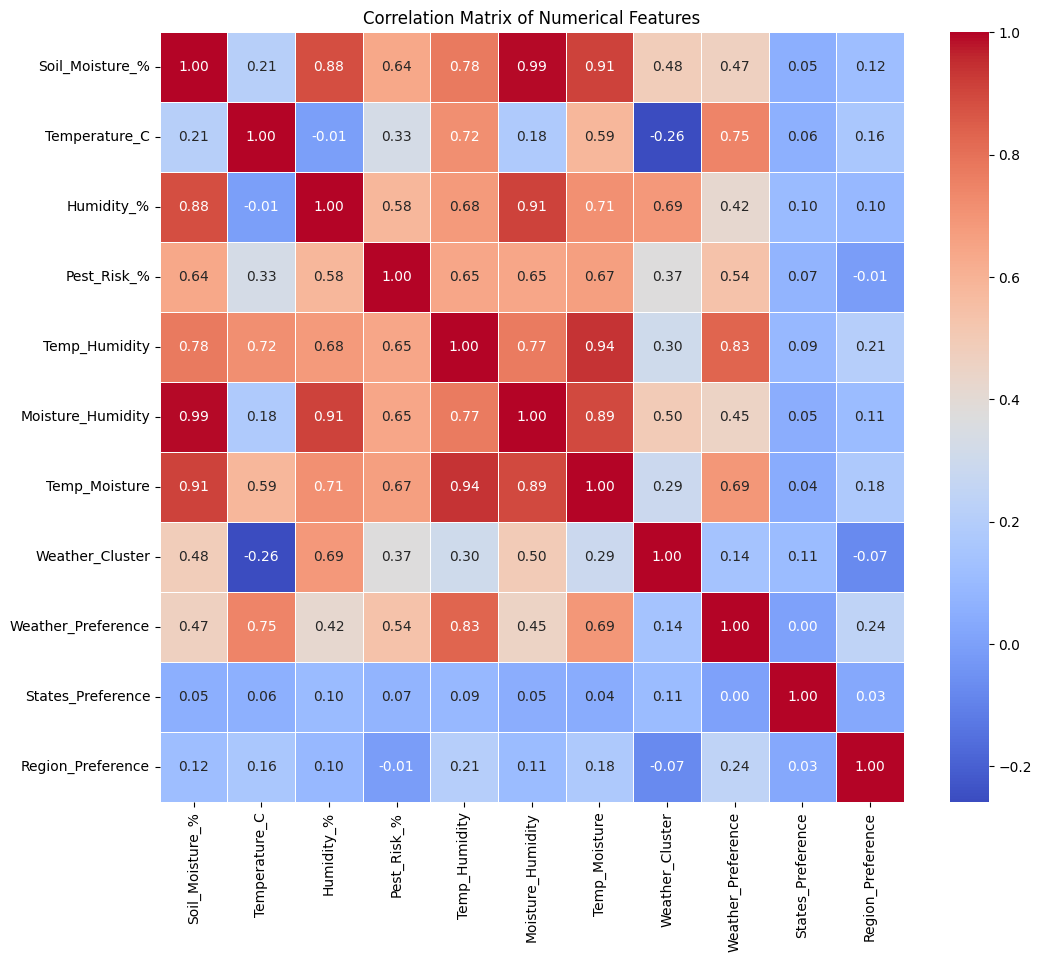

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for correlation analysis
# We'll include the original numerical features, engineered features, and encoded categorical features
correlation_cols = [
    'Soil_Moisture_%', 'Temperature_C', 'Humidity_%', 'Pest_Risk_%',
    'Temp_Humidity', 'Moisture_Humidity', 'Temp_Moisture', 'Weather_Cluster',
    'Weather_Preference', 'States_Preference', 'Region_Preference'
]

# Calculate the correlation matrix
corr_matrix = df[correlation_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

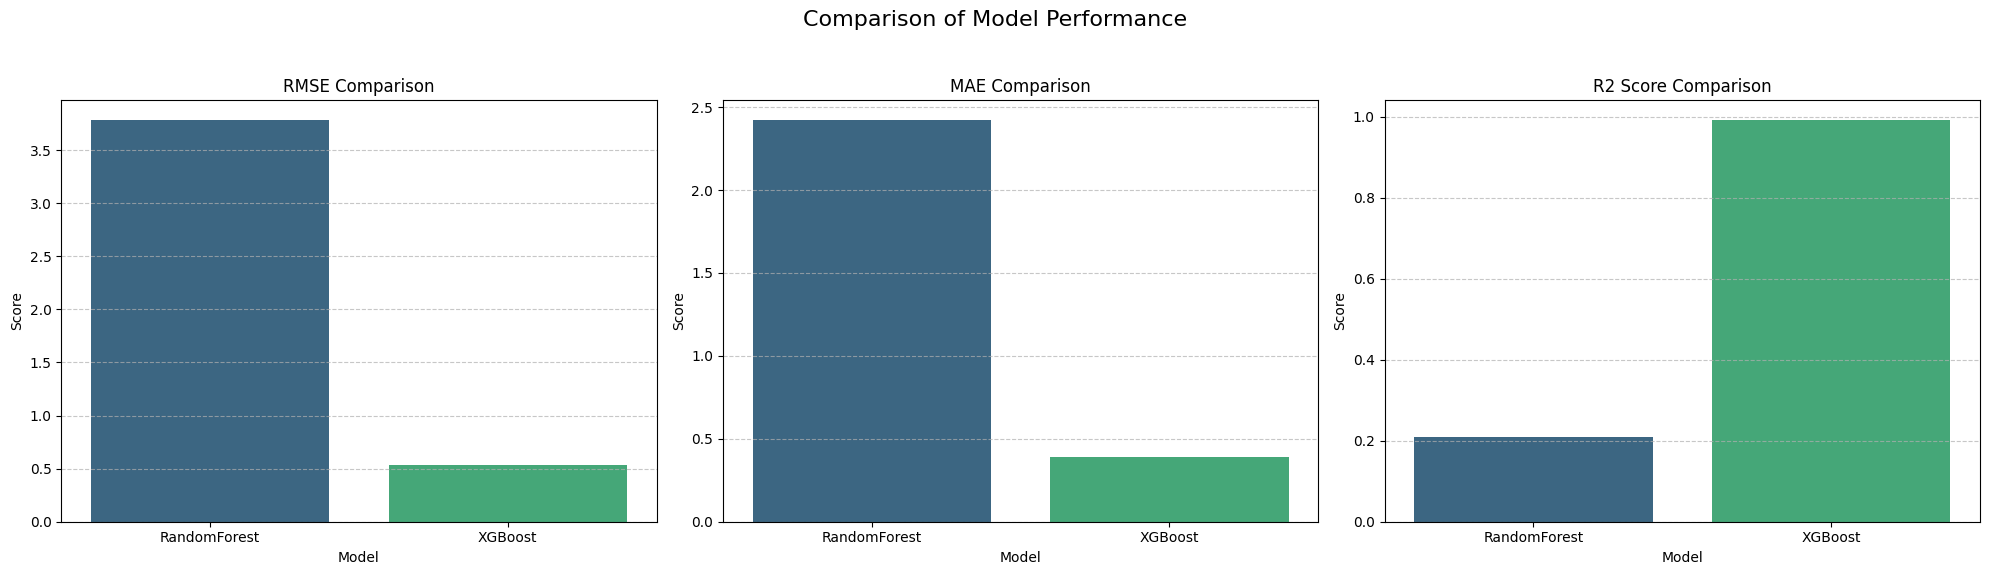

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Performance metrics from the previous executions
# Random Forest metrics from 'BjZrTmGl9McA'
rf_rmse = 3.78
rf_mae = 2.42
rf_r2 = 0.21

# XGBoost metrics from 'Me7uEew93K9G'
xgb_rmse = 0.5308
xgb_mae = 0.3882
xgb_r2 = 0.9909

# Create a DataFrame for easy plotting
metrics_data = {
    'Model': ['RandomForest', 'XGBoost', 'RandomForest', 'XGBoost', 'RandomForest', 'XGBoost'],
    'Metric': ['RMSE', 'RMSE', 'MAE', 'MAE', 'R2 Score', 'R2 Score'],
    'Value': [rf_rmse, xgb_rmse, rf_mae, xgb_mae, rf_r2, xgb_r2]
}

df_metrics = pd.DataFrame(metrics_data)

# Plotting the comparison into separate graphs for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparison of Model Performance', fontsize=16)

metrics = ['RMSE', 'MAE', 'R2 Score']

for i, metric in enumerate(metrics):
    metric_df = df_metrics[df_metrics['Metric'] == metric]
    sns.barplot(x='Model', y='Value', data=metric_df, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel('Score')
    axes[i].set_xlabel('Model')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()